In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch, FontManager
from mplsoccer import Sbopen

import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import optuna
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import cross_val_score
from collections import Counter

import xgboost
from xgboost import XGBClassifier

c:\Oudebestande\FootballDataAnalysis\Scrapers\Scrape-Whoscored-Event-Data-main\Scrape-Whoscored-Event-Data-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# URLs for StatsBomb Open Data
BASE_URL = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/"
COMPETITIONS_URL = BASE_URL + "competitions.json"
MATCHES_URL = BASE_URL + "matches/{competition_id}/{season_id}.json"
EVENTS_URL = BASE_URL + "events/{match_id}.json"
LINEUP_URL = BASE_URL + "lineups/{match_id}.json"


# Functies om data te laden
def load_competitions():
    response = requests.get(COMPETITIONS_URL)
    return pd.DataFrame(response.json())

def load_matches(competition_id, season_id):
    url = MATCHES_URL.format(competition_id=competition_id, season_id=season_id)
    response = requests.get(url)
    return pd.DataFrame(response.json())

def load_events(match_id):
    url = EVENTS_URL.format(match_id=match_id)
    response = requests.get(url)
    return pd.DataFrame(response.json())

#Alle wedstrijden ophalen
competitions = load_competitions()

In [5]:
match_files = []
for _, comp in competitions.iterrows():
    competition_id = comp['competition_id']
    season_id = comp['season_id']
    matches = load_matches(competition_id, season_id)
    match_files.append(matches)

trainings_matches = pd.concat(match_files, ignore_index=True)

In [6]:
shots_data = []
for match_id in trainings_matches['match_id']:
    events = load_events(match_id)
    for _, event in events.iterrows():
        if event['type']['id'] == 16:
            location = event.get('location', [0, 0])
            timestamp = event.get('timestamp')
            period = event.get('period')
            
            
            time_parts = timestamp.split(":")  # Splits "hh:mm:ss.SSS"
            minutes = int(time_parts[1])  # Pak de minuten
            seconds = float(time_parts[2])  # Pak de seconden
            
            
            match_minute = minutes  # Minuut + fractie van seconde
            if period == 2:
                match_minute += 45  # Periode 2 begint bij minuut 45
            
            # Andere velden verwerken
            teamname = event.get('team', {}).get('name')
            player = event.get('player', {}).get('name')
            x, y = location
            distance_to_goal = np.sqrt((120 - x) ** 2 + (40 - y) ** 2)
            angle = np.arctan((7.32 / 2) / distance_to_goal)
            body_part = event.get('shot', {}).get('body_part', {}).get('name', 'Unknown')
            statsbomb_xg = event.get('shot', {}).get('statsbomb_xg')
            end_location_shot = event.get('shot', {}).get('end_location')
            first_touch = event.get('shot', {}).get('first_time')
            shot_specificatie = event.get('shot', {}).get('outcome', {}).get('name')
            situation = event.get('shot', {}).get('type', {}).get('name', 'Unknown')
            under_pressure = event.get('under_pressure', False)
            shot_power = event.get('shot', {}).get('technique', {}).get('name', 'Unknown')
            goal = 1 if event.get('shot', {}).get('outcome', {}).get('name') == 'Goal' else 0
            
            # Match ID correct opslaan per schot
            shots_data.append([
                match_id, teamname, player, timestamp, period, round(match_minute, 1), 
                location, x, y, distance_to_goal, angle, body_part, statsbomb_xg, first_touch,
                situation, end_location_shot, shot_specificatie, under_pressure, shot_power, goal
            ])
# DataFrame aanmaken
columns = ['match_id', 'team', 'player', 'timestamp', 'period', 'minute', 'location', 'x', 'y', 
           'distance_to_goal', 'shot_angle', 'body_part', 'statsbomb_xg', 'first_touch', 'situation','end_location_shot', 'schot_specificatie',
           'under_pressure', 'shot_technique', 'goal']
df = pd.DataFrame(shots_data, columns=columns)

In [7]:
dfsave = df

In [8]:
df['under_pressure'] = df['under_pressure'].fillna('No')
df['under_pressure'] = df['under_pressure'].apply(lambda x: 'No' if x == 'No' or x == False else 'Yes')

In [10]:
from sklearn.preprocessing import LabelEncoder

features = ["x", "y", "distance_to_goal", "shot_angle",
            "body_part", "situation", "first_touch", "shot_technique"]

# Alleen de kolommen die je nodig hebt
df_model = df[features].copy()

# Categoricals binnen jouw feature-set
categorical_columns = ["body_part", "situation", "first_touch", "shot_technique"]
print("Categorische kolommen:", categorical_columns)

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    # Maak alles string + vul missings (LabelEncoder kan niet met NaN)
    df_model[col] = df_model[col].astype(str).fillna("MISSING")
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# mappings printen zoals jij deed
for col, le in label_encoders.items():
    print(f"Label encoding mapping voor {col}:")
    print(dict(zip(le.classes_, le.transform(le.classes_))))
    print()

print(df_model.head())


Categorische kolommen: ['body_part', 'situation', 'first_touch', 'shot_technique']
Label encoding mapping voor body_part:
{'Head': np.int64(0), 'Left Foot': np.int64(1), 'Other': np.int64(2), 'Right Foot': np.int64(3)}

Label encoding mapping voor situation:
{'Corner': np.int64(0), 'Free Kick': np.int64(1), 'Kick Off': np.int64(2), 'Open Play': np.int64(3), 'Penalty': np.int64(4)}

Label encoding mapping voor first_touch:
{'None': np.int64(0), 'True': np.int64(1)}

Label encoding mapping voor shot_technique:
{'Backheel': np.int64(0), 'Diving Header': np.int64(1), 'Half Volley': np.int64(2), 'Lob': np.int64(3), 'Normal': np.int64(4), 'Overhead Kick': np.int64(5), 'Volley': np.int64(6)}

       x     y  distance_to_goal  shot_angle  body_part  situation  \
0  100.4  35.1         20.203218    0.179216          3          3   
1  114.6  33.5          8.450444    0.408723          1          3   
2  106.2  55.8         20.978084    0.172729          1          3   
3  113.9  47.4          9

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# Features en target selecteren
features = ["x", "y", "distance_to_goal", "shot_angle", "body_part", "situation", "first_touch", "shot_technique"]
from sklearn.model_selection import train_test_split

# target
target = "goal"

# voeg target toe aan df_model
df_model[target] = df[target]

# train/test split
train_data, test_data = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model[target]   # belangrijk bij goals (imbalance)
)

# features / target
X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Goal ratio train:", y_train.mean())
print("Goal ratio test:", y_test.mean())



Train shape: (70418, 8)
Test shape: (17605, 8)
Goal ratio train: 0.11122156266863586
Goal ratio test: 0.11121840386253905


In [12]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

import xgboost
from xgboost import XGBClassifier

[I 2026-02-03 21:09:36,271] A new study created in memory with name: no-name-ddae7f71-8b60-4619-8712-6f2c3f3f891a
[I 2026-02-03 21:09:42,656] Trial 0 finished with value: 0.7964578285763348 and parameters: {'n_estimators': 106, 'learning_rate': 0.047585001014085894, 'max_depth': 8, 'subsample': 0.7993292420985183, 'min_child_weight': 2, 'colsample_bytree': 0.5779972601681014}. Best is trial 0 with value: 0.7964578285763348.
[I 2026-02-03 21:09:45,460] Trial 1 finished with value: 0.7980798266994137 and parameters: {'n_estimators': 58, 'learning_rate': 0.043442631142971824, 'max_depth': 7, 'subsample': 0.8540362888980227, 'min_child_weight': 1, 'colsample_bytree': 0.9849549260809971}. Best is trial 1 with value: 0.7980798266994137.
[I 2026-02-03 21:09:51,536] Trial 2 finished with value: 0.7924457627645879 and parameters: {'n_estimators': 175, 'learning_rate': 0.011404616423235533, 'max_depth': 4, 'subsample': 0.5917022549267169, 'min_child_weight': 4, 'colsample_bytree': 0.762378215816

Best hyperparameters: {'n_estimators': 200, 'learning_rate': 0.03256869654451, 'max_depth': 5, 'subsample': 0.7117172729276512, 'min_child_weight': 7, 'colsample_bytree': 0.5070885853360884}
AUC score: 0.8086


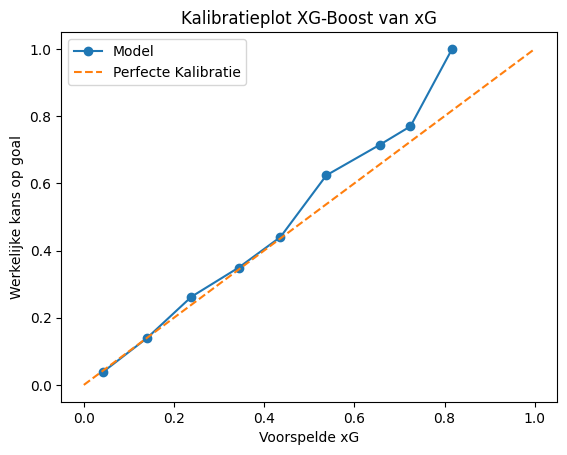

In [16]:
import numpy as np
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def tune_and_evaluate_xgb_optuna(X_train, y_train, X_test, y_test, n_trials=30):
    # Objective function for Optuna to optimize hyperparameters
    def objective_xgb(trial):
        xgb_params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.05),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
        }

        xgb = XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=1,               # voorkom nested parallel issues
            **xgb_params
        )

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Geen make_scorer nodig; dit is robuuster in sklearn 1.8
        scores = cross_val_score(
            xgb,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=1,               # ook hier 1 voor stabiliteit
            error_score=np.nan      # laat NaN terugkomen zodat we het kunnen afvangen
        )

        # Betere NaN check (en je ziet meteen wat er gebeurt)
        if np.isnan(scores).any():
            raise optuna.TrialPruned(f"NaN in fold scores: {scores}")

        return float(np.mean(scores))

    # Create an Optuna study and optimize the objective function
    study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study_xgb.optimize(objective_xgb, n_trials=n_trials)
    
    print("Best hyperparameters:", study_xgb.best_params)

    # Train the model using the best parameters found by Optuna
    best_params = study_xgb.best_params
    xgb_tuned = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=1,
        **best_params
    )
    xgb_tuned.fit(X_train, y_train)
    
    # Make predictions on the test set (probabilities)
    y_pred_proba = xgb_tuned.predict_proba(X_test)[:, 1]
    
    # Calculate AUC score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC score: {auc_score:.4f}")

    # Calibration plot
    prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfecte Kalibratie")
    plt.xlabel("Voorspelde xG")
    plt.ylabel("Werkelijke kans op goal")
    plt.legend()
    plt.title("Kalibratieplot XG-Boost van xG")
    plt.show()

    return xgb_tuned, y_pred_proba, auc_score

# run
xgb_tuned, y_pred_proba, auc_score = tune_and_evaluate_xgb_optuna(X_train, y_train, X_test, y_test, n_trials=30)


In [20]:
import joblib

joblib.dump(xgb_tuned, "xg_model.joblib")
print("Model opgeslagen als xg_model.joblib")



Model opgeslagen als xg_model.joblib


In [21]:
joblib.dump(label_encoders, "label_encoders_xgmodel.joblib")


['label_encoders_xgmodel.joblib']

In [17]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

# Bereken de AUC-scores
auc_existing_xG = roc_auc_score(y_test, existing_xG_scores)
auc_xG = roc_auc_score(y_test, xg_score)

# Bereken de kalibratiecurve voor de drie modellen
fraction_of_positives_existing_xG, mean_predicted_value_existing_xG = calibration_curve(y_test, existing_xG_scores, n_bins=10)
fraction_of_positives_xG, mean_predicted_value_xG = calibration_curve(y_test, xg_score, n_bins=10)


# Plot de kalibratieplots
plt.figure(figsize=(10, 8))

# Calibration plot for existing xG
plt.plot(mean_predicted_value_existing_xG, fraction_of_positives_existing_xG, marker='o', label=f'Existing xG (AUC={auc_existing_xG:.4f})')

# Calibration plot for XG-Boost
plt.plot(mean_predicted_value_xG, fraction_of_positives_xG, marker='s', label=f'XG-Boost xG (AUC={auc_xG:.4f})')


# Add the diagonal (perfect calibration)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Calibration')

# Labels and title
plt.title('Calibration Plots for xG Models')
plt.xlabel('Predicted xG')
plt.ylabel('Actual Probability of Goal')
plt.legend()
plt.savefig("Kalibratieplot.png", bbox_inches='tight')
# Toon de plot
plt.show()

NameError: name 'existing_xG_scores' is not defined